<a href="https://colab.research.google.com/github/Comrade123-123/house-rent-predictor/blob/main/house_rent_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import kagglehub
path = kagglehub.dataset_download("iamsouravbanerjee/house-rent-prediction-dataset")


100%|██████████| 82.4k/82.4k [00:00<00:00, 432kB/s]

Extracting files...


In [5]:
print(path)

/root/.cache/kagglehub/datasets/iamsouravbanerjee/house-rent-prediction-dataset/versions/9


In [6]:
import os

os.listdir(path)

['Dataset Glossary.txt', 'House_Rent_Dataset.csv']

In [7]:
df = pd.read_csv(os.path.join(path, "House_Rent_Dataset.csv"))
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [8]:
df.tail()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent
4745,2022-05-04,2,15000,1000,4 out of 5,Carpet Area,Suchitra Circle,Hyderabad,Unfurnished,Bachelors,2,Contact Owner


In [9]:
df.isnull()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4741,False,False,False,False,False,False,False,False,False,False,False,False
4742,False,False,False,False,False,False,False,False,False,False,False,False
4743,False,False,False,False,False,False,False,False,False,False,False,False
4744,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [11]:
df.isnull().sum()

,0
Posted On,0
BHK,0
Rent,0
Size,0
Floor,0
Area Type,0
Area Locality,0
City,0
Furnishing Status,0
Tenant Preferred,0


In [12]:
df.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

In [13]:
df=df.drop(columns=['Posted On','Tenant Preferred','Point of Contact','Area Type' ])

In [14]:
df.columns

Index(['BHK', 'Rent', 'Size', 'Floor', 'Area Locality', 'City',
       'Furnishing Status', 'Bathroom'],
      dtype='object')

In [15]:
df.duplicated().sum()
df = df.drop_duplicates()

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.shape

(4734, 8)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4734 entries, 0 to 4745
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   BHK                4734 non-null   int64 
 1   Rent               4734 non-null   int64 
 2   Size               4734 non-null   int64 
 3   Floor              4734 non-null   object
 4   Area Locality      4734 non-null   object
 5   City               4734 non-null   object
 6   Furnishing Status  4734 non-null   object
 7   Bathroom           4734 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 332.9+ KB


In [19]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4734.000000,4.734000e+03,4734.000000,4734.000000
mean,2.082805,3.495336e+04,966.962611,1.964723
std,0.831396,7.815931e+04,633.792634,0.883579
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


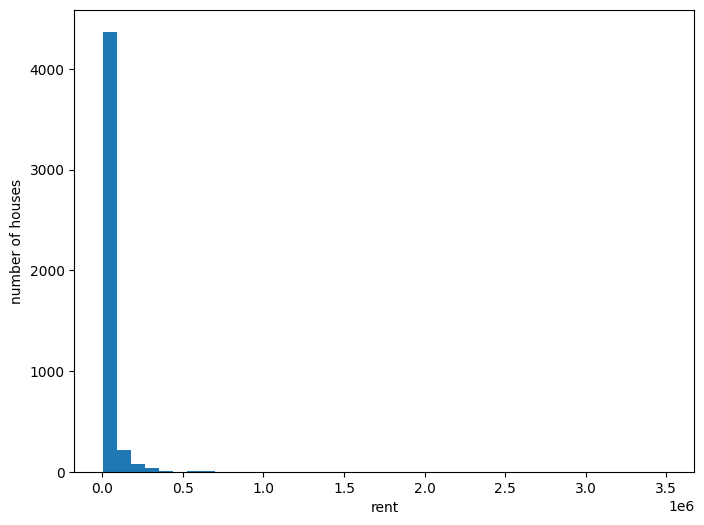

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.hist(df["Rent"],bins = 40)
plt.xlabel("rent")
plt.ylabel("number of houses")
plt.show()

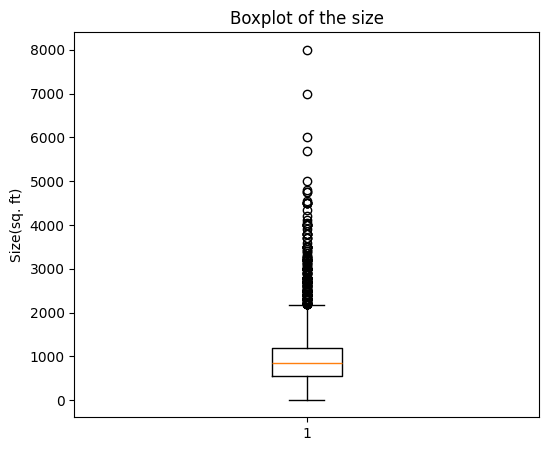

In [21]:
plt.figure(figsize=(6,5))
plt.boxplot(df["Size"])
plt.title("Boxplot of the size")
plt.ylabel("Size(sq. ft)")
plt.show()

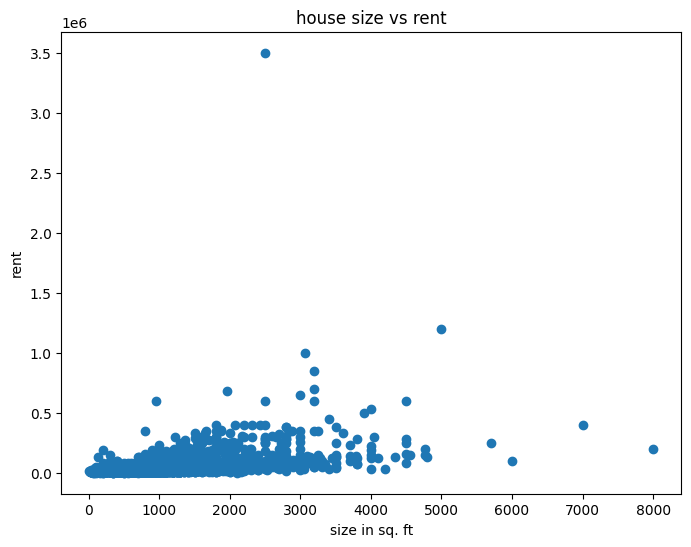

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(df["Size"], df["Rent"])
plt.title("house size vs rent")
plt.xlabel('size in sq. ft')
plt.ylabel('rent')
plt.show()

In [23]:
df.corr(numeric_only=True)

,BHK,Rent,Size,Bathroom
BHK,1.000000,0.369241,0.715416,0.794053
Rent,0.369241,1.000000,0.413733,0.440920
Size,0.715416,0.413733,1.000000,0.740006
Bathroom,0.794053,0.440920,0.740006,1.000000


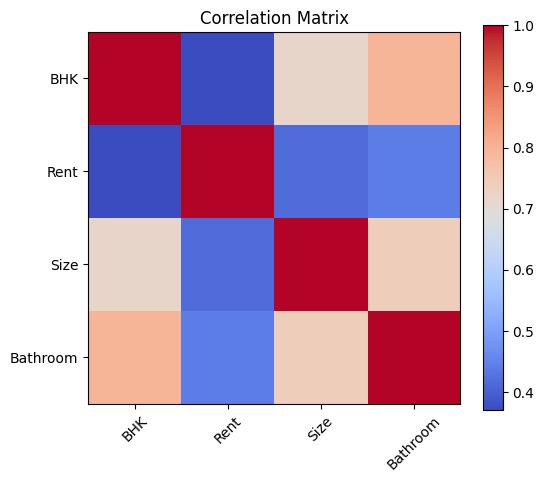

In [24]:
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

In [25]:
df.select_dtypes(include= "object").columns

Index(['Floor', 'Area Locality', 'City', 'Furnishing Status'], dtype='object')

In [26]:
for col in df.select_dtypes(include="object").columns:
  print(f"\n{col}")
  print(df[col].nunique())
  print(df[col].unique()[:10])


Floor
480
['Ground out of 2' '1 out of 3' '1 out of 2' 'Ground out of 1'
 'Ground out of 4' '1 out of 4' '1 out of 1' 'Ground out of 3'
 '2 out of 3' '4 out of 5']

Area Locality
2235
['Bandel' 'Phool Bagan, Kankurgachi' 'Salt Lake City Sector 2'
 'Dumdum Park' 'South Dum Dum' 'Thakurpukur' 'Malancha'
 'Palm Avenue Kolkata, Ballygunge' 'Natunhat'
 'Action Area 1, Rajarhat Newtown']

City
6
['Kolkata' 'Mumbai' 'Bangalore' 'Delhi' 'Chennai' 'Hyderabad']

Furnishing Status
3
['Unfurnished' 'Semi-Furnished' 'Furnished']


In [27]:
for col in df.select_dtypes(include="object").columns:
  print(f"\n==={col}===")
  print(df[col].value_counts())


===Floor===
Floor
1 out of 2         378
Ground out of 2    350
2 out of 3         312
2 out of 4         305
1 out of 3         293
                  ... 
11 out of 17         1
11 out of 16         1
4 out of 26          1
4 out of 31          1
13 out of 25         1
Name: count, Length: 480, dtype: int64

===Area Locality===
Area Locality
Bandra West                     37
Gachibowli                      28
Electronic City                 24
Miyapur, NH 9                   22
Velachery                       22
                                ..
Kadam Tala                       1
Baidyabati                       1
Jagacha                          1
FC Block                         1
Arakere Mico Layout, Arakere     1
Name: count, Length: 2235, dtype: int64

===City===
City
Mumbai       969
Chennai      890
Bangalore    886
Hyderabad    865
Delhi        601
Kolkata      523
Name: count, dtype: int64

===Furnishing Status===
Furnishing Status
Semi-Furnished    2245
Unfurnished       

In [28]:
df["Rent"].describe()

,Rent
count,4.734000e+03
mean,3.495336e+04
std,7.815931e+04
min,1.200000e+03
25%,1.000000e+04
50%,1.600000e+04
75%,3.300000e+04
max,3.500000e+06


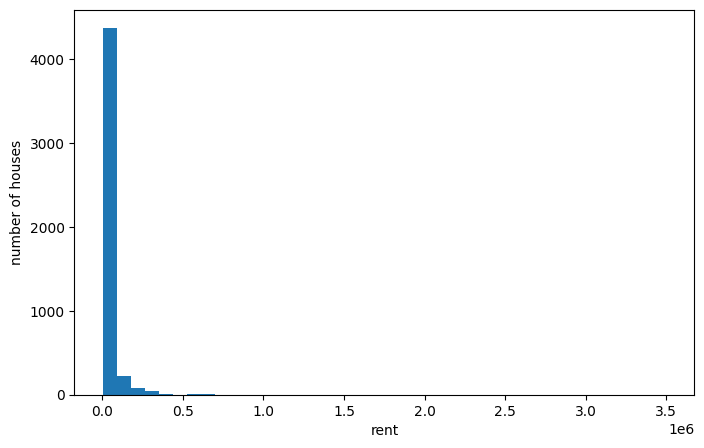

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["Rent"],bins = 40)
plt.xlabel("rent")
plt.ylabel("number of houses")
plt.show()


In [30]:
df["Floor"].head(10)

,Floor
0,Ground out of 2
1,1 out of 3
2,1 out of 3
3,1 out of 2
4,1 out of 2
5,Ground out of 1
6,Ground out of 4
7,1 out of 2
8,1 out of 2
9,1 out of 3


In [46]:
floor_split = df["Floor"].str.split(" out of ", expand=True, n=1)

In [48]:
floor_split = floor_split.iloc[:, :2]
floor_split.columns = ["Current Floor", "Total floor"]
floor_split.shape


(4734, 2)

In [49]:
floor_split.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4734 entries, 0 to 4745
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Current Floor  4734 non-null   object
 1   Total floor    4730 non-null   object
dtypes: object(2)
memory usage: 111.0+ KB


In [54]:
df.reset_index(drop=True, inplace=True)

In [56]:
floor_split[floor_split["Total floor"].isna()]

,Current Floor,Total floor
2549,3,None
2875,Ground,None
4480,1,None
4549,1,None
